In [1]:
import torch 
from torch import nn 
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import subprocess
import os 

Class sizes: [5000, 1581, 500, 158, 50] (approx imb-ratio=100.0)
Observation iter (first full): it=9 | sim ended it=9


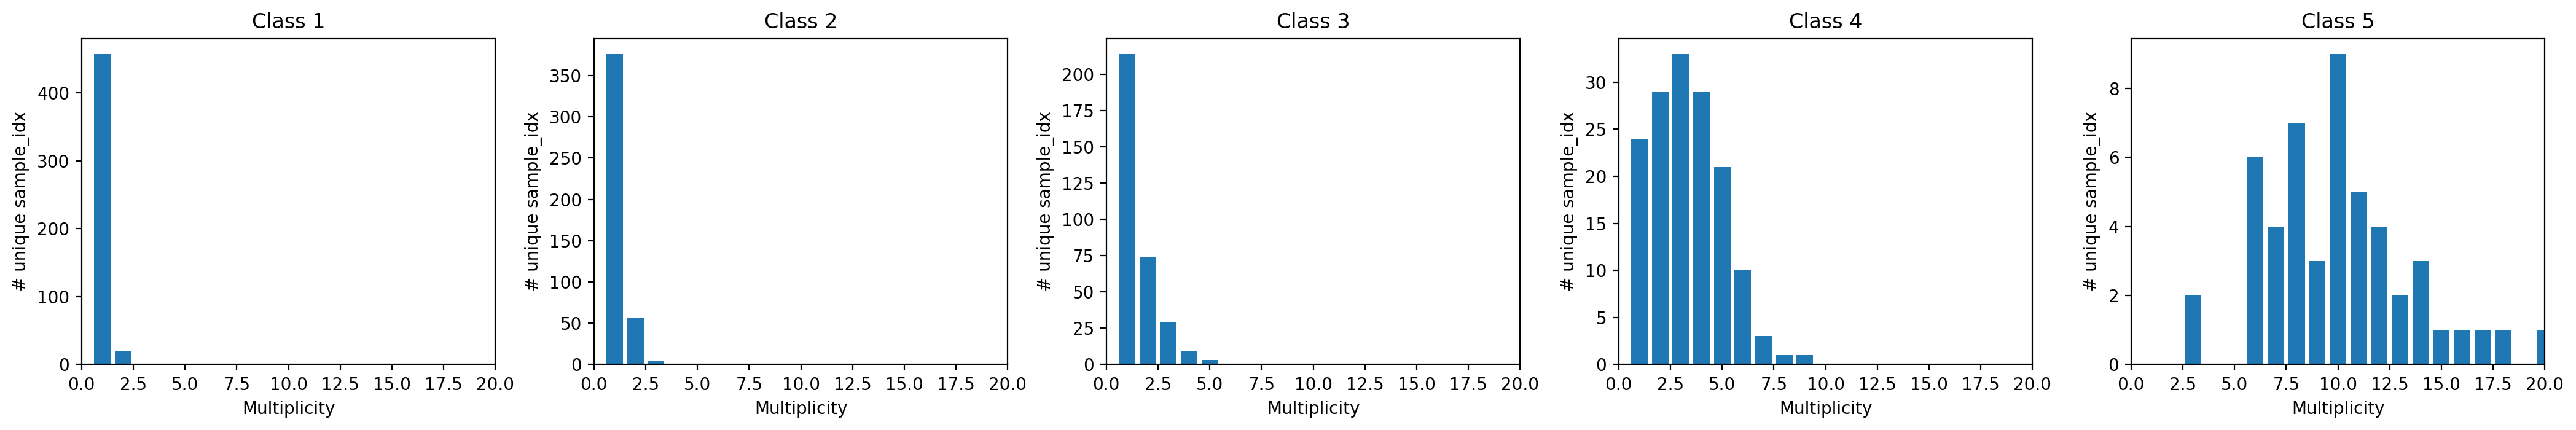

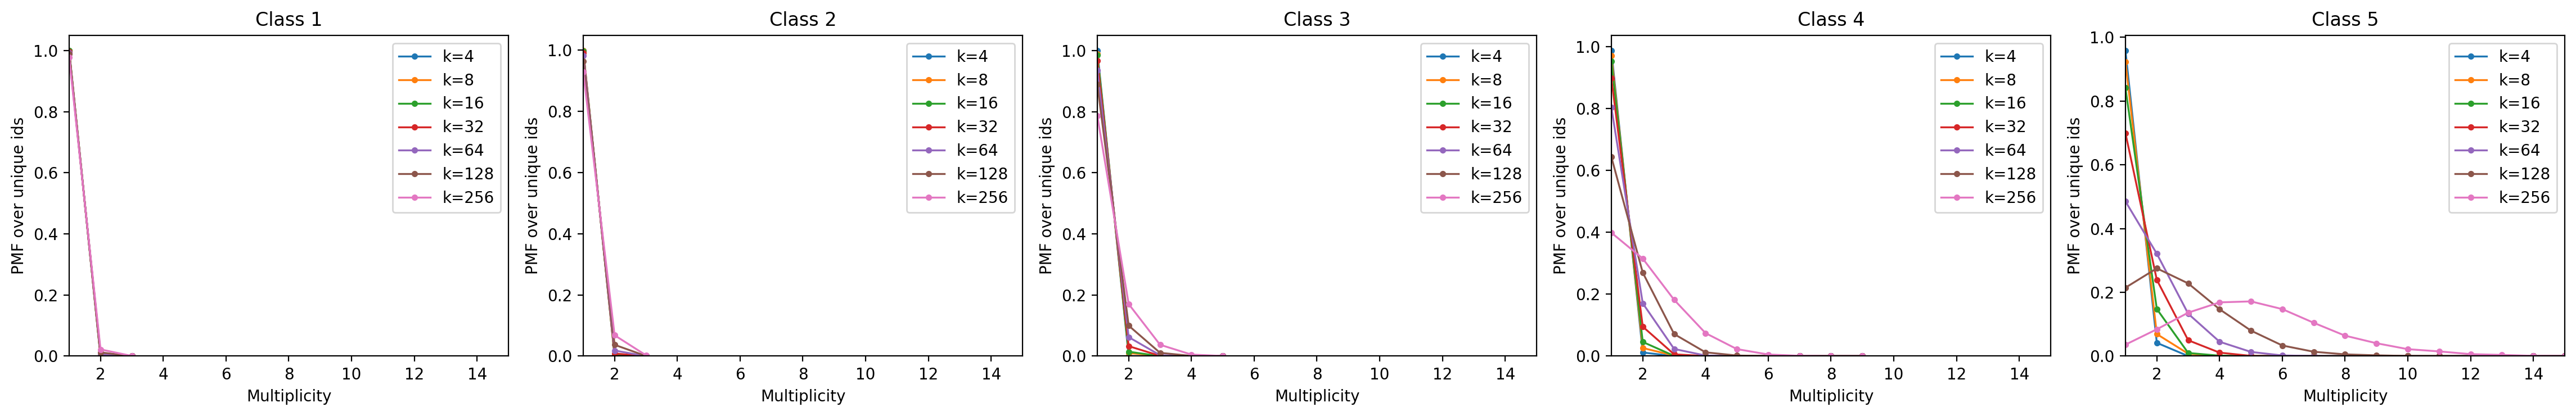

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, deque

# High-DPI rendering (inline + savefig)
plt.rcParams.update({
    "figure.dpi": 200,   # notebook display
    "savefig.dpi": 300,  # files saved via plt.savefig
})


# ----------------------------
# 1) Config
# ----------------------------
SEED = 42
NUM_CLASSES = 5

N_MAX = 5000
IMB_RATIO = 100  # n_max / n_min (approx)

# balanced sampling batch
BATCH_SIZE = 250
assert BATCH_SIZE % NUM_CLASSES == 0
BATCH_PER_CLASS = BATCH_SIZE // NUM_CLASSES

# memory bank capacity (클래스별로 다르게 확장 가능)
MEM_CAPACITY = [500] * NUM_CLASSES  # e.g. [500, 500, 300, 200, 100]

# observation time: "all banks first become full"
ALSO_MEASURE_AFTER_EXTRA_ITERS = False
EXTRA_ITERS_AFTER_FULL = 2000

# subset sizes to probe (S_c sizes)
SUBSET_SIZES = [4, 8, 16, 32, 64, 128, 256]  # 자동으로 cap에 맞춰 잘림
SUBSET_TRIALS = 200  # subset sampling은 랜덤이라 여러번 평균내는 게 안정적


# ----------------------------
# 2) Long-tail class sizes (exponential)
# ----------------------------
def make_exp_longtail_sizes(num_classes, n_max, imb_ratio):
    # n_c = n_max * imb_ratio^(-c/(C-1))
    sizes = []
    for c in range(num_classes):
        exponent = -c / (num_classes - 1)
        n_c = int(round(n_max * (imb_ratio ** exponent)))
        sizes.append(max(1, n_c))
    return sizes


def build_class_index_pools(class_sizes):
    pools = []
    start = 0
    for n in class_sizes:
        pools.append(np.arange(start, start + n, dtype=np.int64))
        start += n
    return pools


# ----------------------------
# 3) Simulation: balanced sampling -> fill banks with (iter_idx, sample_idx)
# ----------------------------
def run_simulation(class_pools, mem_capacity, batch_per_class, rng,
                   also_measure_after_extra=False, extra_iters_after_full=0):
    num_classes = len(class_pools)
    banks = [deque(maxlen=mem_capacity[c]) for c in range(num_classes)]

    first_full_iter = None
    it = 0
    while True:
        # balanced sampling (per-class, with replacement)
        for c in range(num_classes):
            pool = class_pools[c]
            sampled = rng.choice(pool, size=batch_per_class, replace=True)
            for sid in sampled:
                banks[c].append((it, int(sid)))

        # first time all banks full
        if first_full_iter is None:
            if all(len(banks[c]) >= mem_capacity[c] for c in range(num_classes)):
                first_full_iter = it
                if not also_measure_after_extra:
                    break

        # optional extra iters after full
        if also_measure_after_extra and first_full_iter is not None:
            if it >= first_full_iter + extra_iters_after_full:
                break

        it += 1

    return banks, first_full_iter, it


# ----------------------------
# 4) Duplicate stats helpers
# ----------------------------
def multiplicity_counts_from_entries(entries):
    # entries: list[(iter_idx, sample_idx)]
    sids = [sid for _, sid in entries]
    counts = Counter(sids)
    mult = np.array(list(counts.values()), dtype=np.int64)  # multiplicities per unique sid
    return mult, counts


def multiplicity_hist(mult):
    # returns freq[k] = number of unique sample_idx that appear k times (k>=1)
    if mult.size == 0:
        return np.array([0], dtype=np.int64)
    max_mult = int(mult.max())
    freq = np.bincount(mult, minlength=max_mult + 1)  # freq[0] unused
    return freq  # includes freq[0]


# ----------------------------
# 5) Plot 1: full bank duplication hist (one figure, subplots per class)
# ----------------------------
def plot_fullbank_hist(banks, class_sizes, title_suffix="(observation)"):
    num_classes = len(banks)

    # decide global max x for nicer alignment (optional)
    all_max = 1
    per_class_freq = []
    for c in range(num_classes):
        mult, _ = multiplicity_counts_from_entries(list(banks[c]))
        freq = multiplicity_hist(mult)
        per_class_freq.append(freq)
        all_max = max(all_max, len(freq) - 1)

    fig, axes = plt.subplots(1, num_classes, figsize=(4.2 * num_classes, 3.6), sharey=False)
    if num_classes == 1:
        axes = [axes]

    for c, ax in enumerate(axes):
        freq = per_class_freq[c]
        max_k = len(freq) - 1
        ks = np.arange(1, max_k + 1)
        ys = freq[1:]
        ax.set_xlim(0,20)
        ax.bar(ks, ys)
        ax.set_xlabel("Multiplicity")
        ax.set_ylabel("# unique sample_idx")
        ax.set_title(f"Class {c+1}")

    fig.tight_layout()
    plt.show()


# ----------------------------
# 6) Plot 2: subset S_c duplication distribution across subset sizes
#    - bank fixed at observation time
#    - for each k: sample k entries WITHOUT replacement from the bank
#    - compute histogram over multiplicity of unique ids, normalize to a PMF over unique ids
# ----------------------------
def estimate_subset_pmf_for_class(bank_entries, subset_sizes, trials, rng):
    """
    Returns:
      pmfs[k] = 1D array p(m) for m=1..M (PMF over multiplicity of unique ids within subset)
    """
    bank_size = len(bank_entries)
    idxs = np.arange(bank_size)

    pmfs = {}
    for k in subset_sizes:
        k_eff = min(k, bank_size)
        if k_eff <= 0:
            continue

        acc = None
        acc_count = 0

        for _ in range(trials):
            chosen = rng.choice(idxs, size=k_eff, replace=False)
            subset = [bank_entries[i] for i in chosen]
            mult, _ = multiplicity_counts_from_entries(subset)
            freq = multiplicity_hist(mult)  # freq[0] unused
            vec = freq[1:].astype(np.float64)

            # normalize to PMF over unique ids (sum = 1)
            s = vec.sum()
            if s <= 0:
                continue
            vec /= s

            if acc is None:
                acc = vec
            else:
                # pad if needed (in case max multiplicity differs across trials)
                if vec.shape[0] > acc.shape[0]:
                    acc = np.pad(acc, (0, vec.shape[0] - acc.shape[0]))
                elif vec.shape[0] < acc.shape[0]:
                    vec = np.pad(vec, (0, acc.shape[0] - vec.shape[0]))
                acc += vec

            acc_count += 1

        if acc is None or acc_count == 0:
            pmfs[k_eff] = np.array([1.0])  # degenerate fallback
        else:
            pmfs[k_eff] = acc / acc_count

    return pmfs


def plot_subset_pmfs(banks, class_sizes, subset_sizes, trials, seed, title_suffix="(observation)"):
    num_classes = len(banks)
    rng = np.random.default_rng(seed)

    # per-class pmfs
    per_class_pmfs = []
    for c in range(num_classes):
        entries = list(banks[c])
        pmfs = estimate_subset_pmf_for_class(entries, subset_sizes, trials, rng)
        per_class_pmfs.append(pmfs)

    fig, axes = plt.subplots(1, num_classes, figsize=(4.6 * num_classes, 3.8), sharey=False)
    if num_classes == 1:
        axes = [axes]

    # global legend handles
    handles, labels = None, None

    for c, ax in enumerate(axes):
        pmfs = per_class_pmfs[c]

        # sort by k (effective)
        ks_sorted = sorted(pmfs.keys())
        max_m = max(len(pmfs[k]) for k in ks_sorted) if ks_sorted else 1
        xs = np.arange(1, max_m + 1)

        for k in ks_sorted:
            p = pmfs[k]
            y = np.pad(p, (0, max_m - len(p)))
            h = ax.plot(xs, y, marker="o", linewidth=1.2, markersize=3, label=f"k={k}")


        ax.set_xlabel("Multiplicity")
        ax.set_ylabel("PMF over unique ids")
        ax.set_title(f"Class {c+1}")
        ax.set_xlim(1, 15)
        ax.set_ylim(bottom=0)
        ax.legend()
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    # one shared legend for the whole figure
    fig.tight_layout()
    plt.show()


# ----------------------------
# 7) Main
# ----------------------------
def main():
    rng = np.random.default_rng(SEED)

    class_sizes = make_exp_longtail_sizes(NUM_CLASSES, N_MAX, IMB_RATIO)
    print("Class sizes:", class_sizes, f"(approx imb-ratio={class_sizes[0]/class_sizes[-1]:.1f})")

    class_pools = build_class_index_pools(class_sizes)

    banks, first_full_iter, last_iter = run_simulation(
        class_pools=class_pools,
        mem_capacity=MEM_CAPACITY,
        batch_per_class=BATCH_PER_CLASS,
        rng=rng,
        also_measure_after_extra=ALSO_MEASURE_AFTER_EXTRA_ITERS,
        extra_iters_after_full=EXTRA_ITERS_AFTER_FULL,
    )
    print(f"Observation iter (first full): it={first_full_iter} | sim ended it={last_iter}")

    title_suffix = "(first full)" if not ALSO_MEASURE_AFTER_EXTRA_ITERS else f"(after +{EXTRA_ITERS_AFTER_FULL} iters)"

    # 1) full bank histogram (one figure, 1x5 subplots)
    plot_fullbank_hist(banks, class_sizes, title_suffix=title_suffix)

    # 2) subset duplication distributions across k (one figure, 1x5 subplots)
    #    (cap subset sizes to each bank automatically inside)
    plot_subset_pmfs(
        banks=banks,
        class_sizes=class_sizes,
        subset_sizes=SUBSET_SIZES,
        trials=SUBSET_TRIALS,
        seed=SEED + 999,  # separate RNG stream from fill sim
        title_suffix=title_suffix,
    )


if __name__ == "__main__":
    main()


Dataset class sizes: [5000, 1581, 500, 158, 50] (approx imb-ratio=100.0)
Memory capacities: [1000, 316, 100, 32, 10]
Observation iteration (first all-full): it=19


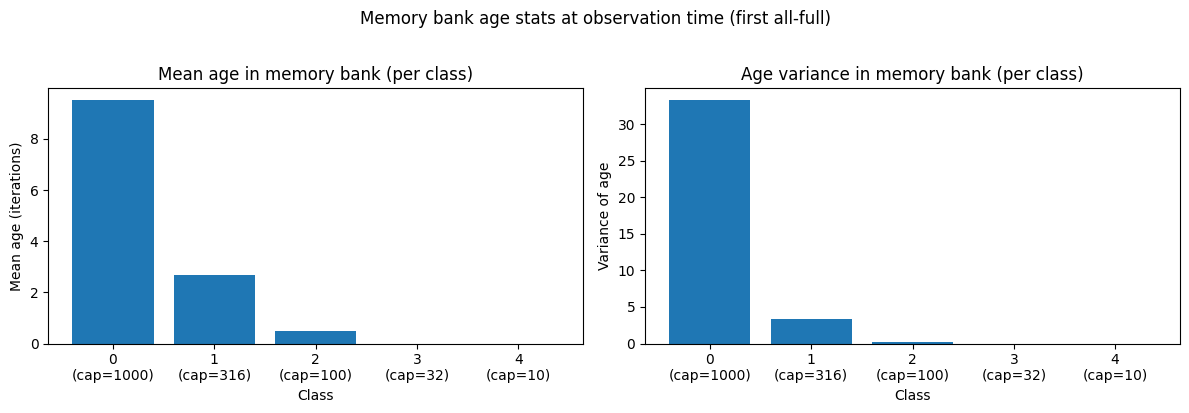

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ----------------------------
# Config (same as before except mem capacities)
# ----------------------------
SEED = 42
NUM_CLASSES = 5

N_MAX = 5000
IMB_RATIO = 100  # dataset long-tail

BATCH_SIZE = 250
assert BATCH_SIZE % NUM_CLASSES == 0
BATCH_PER_CLASS = BATCH_SIZE // NUM_CLASSES

# NEW: per-class memory capacity (exp-decay from head=1000 to tail=10)
MEM_HEAD = 1000
MEM_TAIL = 10


# ----------------------------
# Helpers
# ----------------------------
def make_exp_longtail_sizes(num_classes, n_max, imb_ratio):
    # n_c = n_max * imb_ratio^(-c/(C-1))
    sizes = []
    for c in range(num_classes):
        exponent = -c / (num_classes - 1)
        n_c = int(round(n_max * (imb_ratio ** exponent)))
        sizes.append(max(1, n_c))
    return sizes


def build_class_index_pools(class_sizes):
    pools = []
    start = 0
    for n in class_sizes:
        pools.append(np.arange(start, start + n, dtype=np.int64))
        start += n
    return pools


def make_exp_mem_caps(num_classes, head, tail):
    # cap_c = head * (head/tail)^(-c/(C-1))  -> exp decay head -> tail
    ratio = head / tail
    caps = []
    for c in range(num_classes):
        exponent = -c / (num_classes - 1)
        cap = int(round(head * (ratio ** exponent)))
        caps.append(max(1, cap))
    # ensure exact endpoints after rounding (optional but nice)
    caps[0] = head
    caps[-1] = tail
    return caps


def run_fill_until_all_full(class_pools, mem_caps, batch_per_class, rng):
    """
    Fill memory banks with (iter_idx, sample_idx) using balanced sampling.
    Stop at the first iteration where ALL banks are full.
    """
    num_classes = len(class_pools)
    banks = [deque(maxlen=mem_caps[c]) for c in range(num_classes)]

    it = 0
    while True:
        # balanced sampling per class (with replacement)
        for c in range(num_classes):
            pool = class_pools[c]
            sampled = rng.choice(pool, size=batch_per_class, replace=True)
            for sid in sampled:
                banks[c].append((it, int(sid)))

        if all(len(banks[c]) >= mem_caps[c] for c in range(num_classes)):
            obs_it = it
            break

        it += 1

    return banks, obs_it


def compute_age_stats(banks, obs_it):
    """
    For each class: ages = obs_it - iter_idx for all entries in bank.
    Return mean and variance (ddof=0) per class.
    """
    means = []
    vars_ = []
    for bank in banks:
        it_ins = np.array([it for it, _ in bank], dtype=np.int64)
        ages = (obs_it - it_ins).astype(np.float64)
        means.append(float(ages.mean()) if ages.size else float("nan"))
        vars_.append(float(ages.var(ddof=0)) if ages.size else float("nan"))
    return np.array(means), np.array(vars_)


# ----------------------------
# Main
# ----------------------------
def main():
    rng = np.random.default_rng(SEED)

    class_sizes = make_exp_longtail_sizes(NUM_CLASSES, N_MAX, IMB_RATIO)
    mem_caps = make_exp_mem_caps(NUM_CLASSES, MEM_HEAD, MEM_TAIL)
    class_pools = build_class_index_pools(class_sizes)

    print("Dataset class sizes:", class_sizes, f"(approx imb-ratio={class_sizes[0]/class_sizes[-1]:.1f})")
    print("Memory capacities:", mem_caps)

    banks, obs_it = run_fill_until_all_full(
        class_pools=class_pools,
        mem_caps=mem_caps,
        batch_per_class=BATCH_PER_CLASS,
        rng=rng,
    )
    print(f"Observation iteration (first all-full): it={obs_it}")

    mean_age, var_age = compute_age_stats(banks, obs_it)

    # ----------------------------
    # Plot: 1 figure, 2 subplots
    # ----------------------------
    classes = np.arange(NUM_CLASSES)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    # (1) Mean age barplot
    axes[0].bar(classes, mean_age)
    axes[0].set_title("Mean age in memory bank (per class)")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Mean age (iterations)")
    axes[0].set_xticks(classes)
    axes[0].set_xticklabels([f"{c}\n(cap={mem_caps[c]})" for c in classes])

    # (2) Variance of age barplot
    axes[1].bar(classes, var_age)
    axes[1].set_title("Age variance in memory bank (per class)")
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Variance of age")
    axes[1].set_xticks(classes)
    axes[1].set_xticklabels([f"{c}\n(cap={mem_caps[c]})" for c in classes])

    fig.suptitle("Memory bank age stats at observation time (first all-full)", y=1.02)
    fig.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


In [6]:
import torch 
url = "https://dl.fbaipublicfiles.com/moco-v3/vit-b-300ep/vit-b-300ep.pth.tar"
ckpt = torch.hub.load_state_dict_from_url(url, map_location="cpu")

Downloading: "https://dl.fbaipublicfiles.com/moco-v3/vit-b-300ep/vit-b-300ep.pth.tar" to /Users/seominjae/.cache/torch/hub/checkpoints/vit-b-300ep.pth.tar
100%|██████████| 823M/823M [01:26<00:00, 9.96MB/s] 


In [4]:
betas = [0.3, 0.7, 1, 2]
micro_accs=[68.11,68.31,68.49,68.23]
macro_accs = micro_accs
dataset_names = ['AffectNet7']*4


In [5]:
# Add new data to gamma DataFrame
new_data = pd.DataFrame({
    'beta': betas,
    'micro_acc': micro_accs,
    'macro_acc': macro_accs,
    'dataset_name': dataset_names
})

gamma = pd.concat([gamma, new_data], ignore_index=True)
gamma.to_csv('results/betas.csv', index=False)
print(f"Added {len(new_data)} rows to gamma DataFrame")
print(gamma.tail())


Added 4 rows to gamma DataFrame
   beta  micro_acc  macro_acc dataset_name
3   2.0      92.50      87.44       RAF-DB
4   0.3      68.11      68.11   AffectNet7
5   0.7      68.31      68.31   AffectNet7
6   1.0      68.49      68.49   AffectNet7
7   2.0      68.23      68.23   AffectNet7


In [ ]:
# Beta vs Micro/Macro Accuracy Plot with Dual Y-Axes - Separate plots for each dataset
datasets = gamma['dataset_name'].unique()

# Function to create plot for a specific dataset
def plot_beta_accuracy(dataset_name, save_filename):
    data = gamma[gamma['dataset_name'] == dataset_name].sort_values('beta')
    
    fig, ax1 = plt.subplots(figsize=(12, 8), dpi=800)
    
    # Plot Micro Accuracy (left y-axis)
    line_micro, = ax1.plot(data['beta'], data['micro_acc'], marker='o', linewidth=2.5, markersize=10, 
                          color='#2E86AB', alpha=0.8, linestyle='-', label='Micro Accuracy')
    
    ax1.set_xlabel(r'$\lambda$ Parameter', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Micro Accuracy (%)', fontsize=14, fontweight='bold', color='#2E86AB')
    ax1.set_title(f'Impact of $\lambda$ Parameter on Micro and Macro Accuracy - {dataset_name}', 
                  fontsize=16, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#2E86AB')
    ax1.grid(True, alpha=0.3)
    
    # Set x-axis ticks to match beta values
    beta_ticks = sorted(data['beta'].unique())
    ax1.set_xticks(beta_ticks)
    ax1.set_xticklabels([f'{tick:.1f}' for tick in beta_ticks], fontsize=11)
    
    # Create right y-axis for Macro Accuracy
    ax2 = ax1.twinx()
    line_macro, = ax2.plot(data['beta'], data['macro_acc'], marker='s', linewidth=2.5, markersize=10, 
                          color='#F18F01', alpha=0.8, linestyle='--', label='Macro Accuracy')
    
    ax2.set_ylabel('Macro Accuracy (%)', fontsize=14, fontweight='bold', color='#F18F01')
    ax2.tick_params(axis='y', labelcolor='#F18F01')
    
    # Set x-axis ticks for ax2 (same as ax1)
    ax2.set_xticks(beta_ticks)
    ax2.set_xticklabels([f'{tick:.1f}' for tick in beta_ticks], fontsize=11)
    
    # Set appropriate y-limits
    micro_min, micro_max = data['micro_acc'].min(), data['micro_acc'].max()
    macro_min, macro_max = data['macro_acc'].min(), data['macro_acc'].max()
    
    ax1.set_ylim([micro_min - 1, micro_max + 1])
    ax2.set_ylim([macro_min - 1, macro_max + 1])
    
    # Create combined legend
    lines = [line_micro, line_macro]
    labels = ['Micro Accuracy', 'Macro Accuracy']
    ax1.legend(lines, labels, fontsize=12, loc='upper right')
    
    plt.tight_layout()
    plt.savefig(save_filename, dpi=800, bbox_inches='tight')
    plt.show()

# Plot for each dataset
for dataset in datasets:
    dataset_safe_name = dataset.replace(' ', '_').lower()
    save_filename = f'results/beta_accuracy_dual_axis_{dataset_safe_name}.png'
    plot_beta_accuracy(dataset, save_filename)

# Print summary statistics
print("\n=== Beta vs Accuracy Summary ===")
for dataset in datasets:
    data = gamma[gamma['dataset_name'] == dataset]
    print(f"\n{dataset}:")
    print(f"  Beta range: {data['beta'].min():.2f} - {data['beta'].max():.2f}")
    print(f"  Micro Acc range: {data['micro_acc'].min():.2f} - {data['micro_acc'].max():.2f}")
    print(f"  Macro Acc range: {data['macro_acc'].min():.2f} - {data['macro_acc'].max():.2f}")
    print(f"  Best Micro Acc: {data['micro_acc'].max():.2f} at beta={data.loc[data['micro_acc'].idxmax(), 'beta']:.2f}")
    print(f"  Best Macro Acc: {data['macro_acc'].max():.2f} at beta={data.loc[data['macro_acc'].idxmax(), 'beta']:.2f}")



=== Beta vs Accuracy Summary ===

RAF-DB:
  Beta range: 0.30 - 2.00
  Micro Acc range: 92.37 - 93.03
  Macro Acc range: 86.12 - 87.82
  Best Micro Acc: 93.03 at beta=1.00
  Best Macro Acc: 87.82 at beta=1.00


In [7]:
gamma = pd.DataFrame(None, columns=['beta', 'micro_acc', 'macro_acc', 'dataset_name'])
betas = [0.3, 0.7, 1, 2]
micro_accs = [92.37,92.37,93.03,92.50]
macro_accs = [86.12,86.64, 87.82, 87.44]
dataset_names = ['RAF-DB']*4
gamma = pd.DataFrame({
    'beta': betas,
    'micro_acc': micro_accs,
    'macro_acc': macro_accs,
    'dataset_name': dataset_names
})

gamma.to_csv('results/betas.csv', index=False)

In [ ]:
gamma.head()

In [3]:
gamma_beta = pd.read_csv('results/gamma_beta.csv')
k_param = pd.read_csv('results/k_param.csv')

In [7]:
k_param.loc[len(k_param)] = {'k': 64, 'acc': 92.57, 'dataset': 'RAF-DB'}
k_param.loc[len(k_param)] = {'k': 64, 'acc': 68.14, 'dataset': 'AffectNet7'}

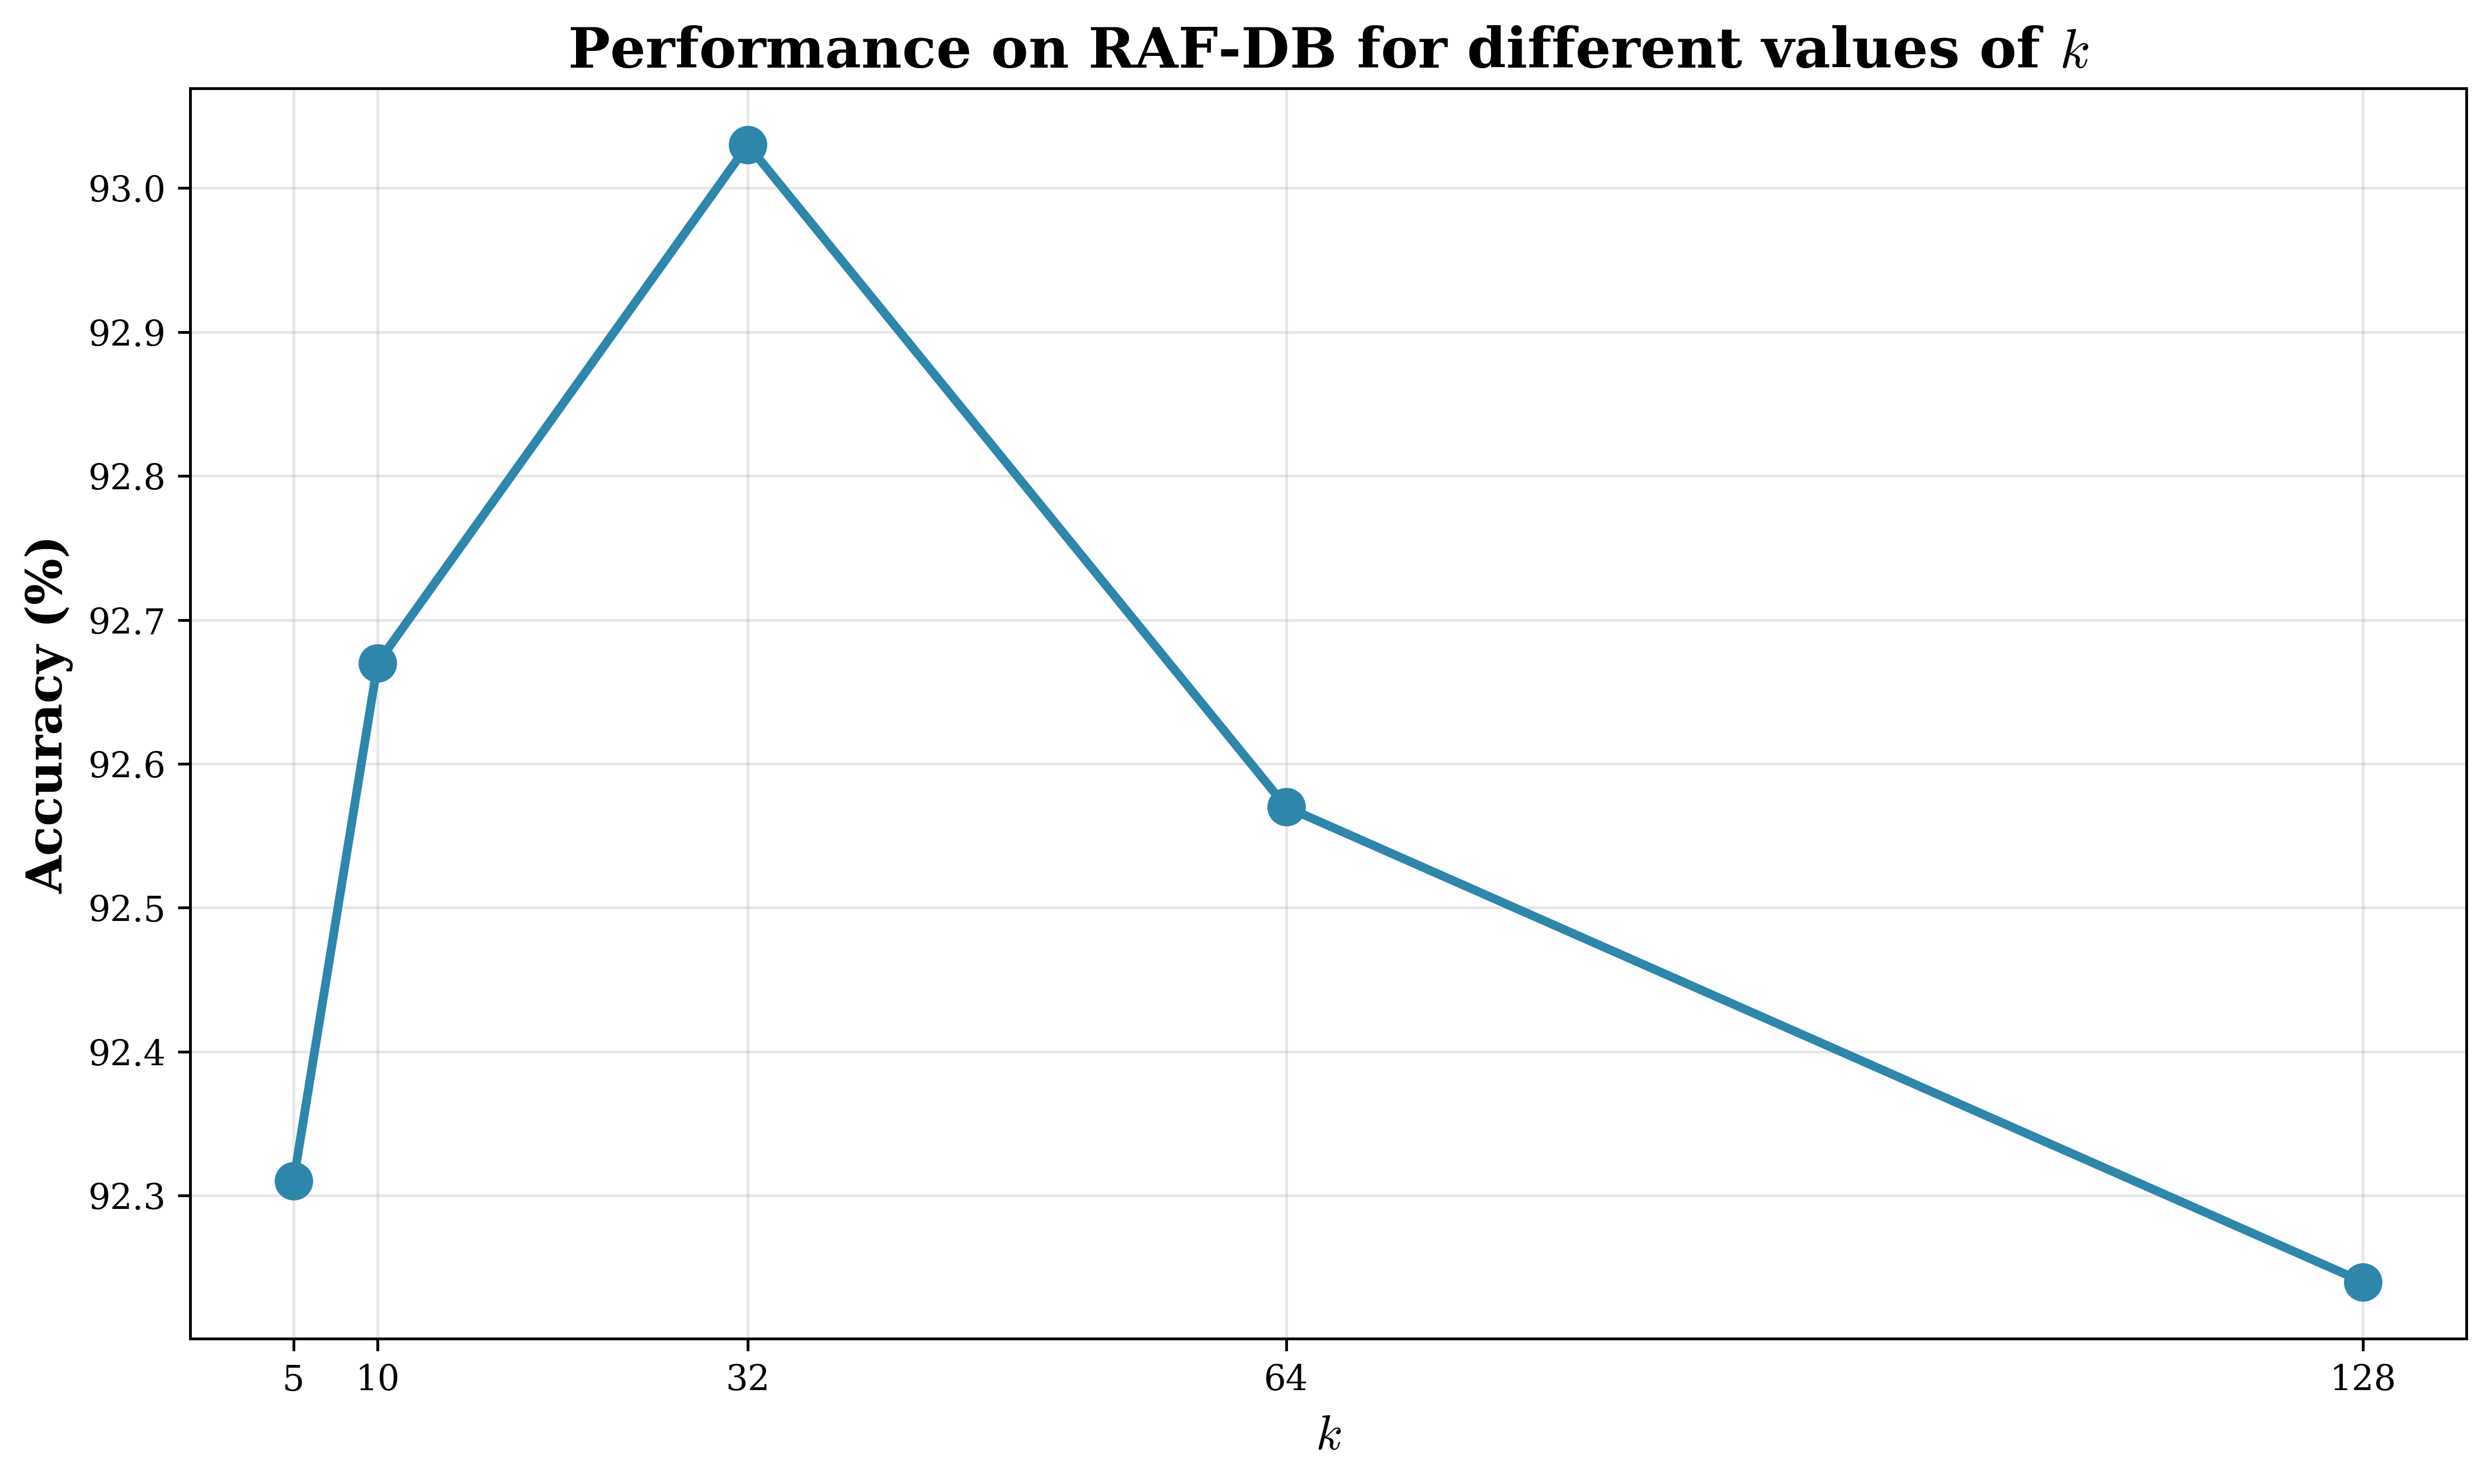

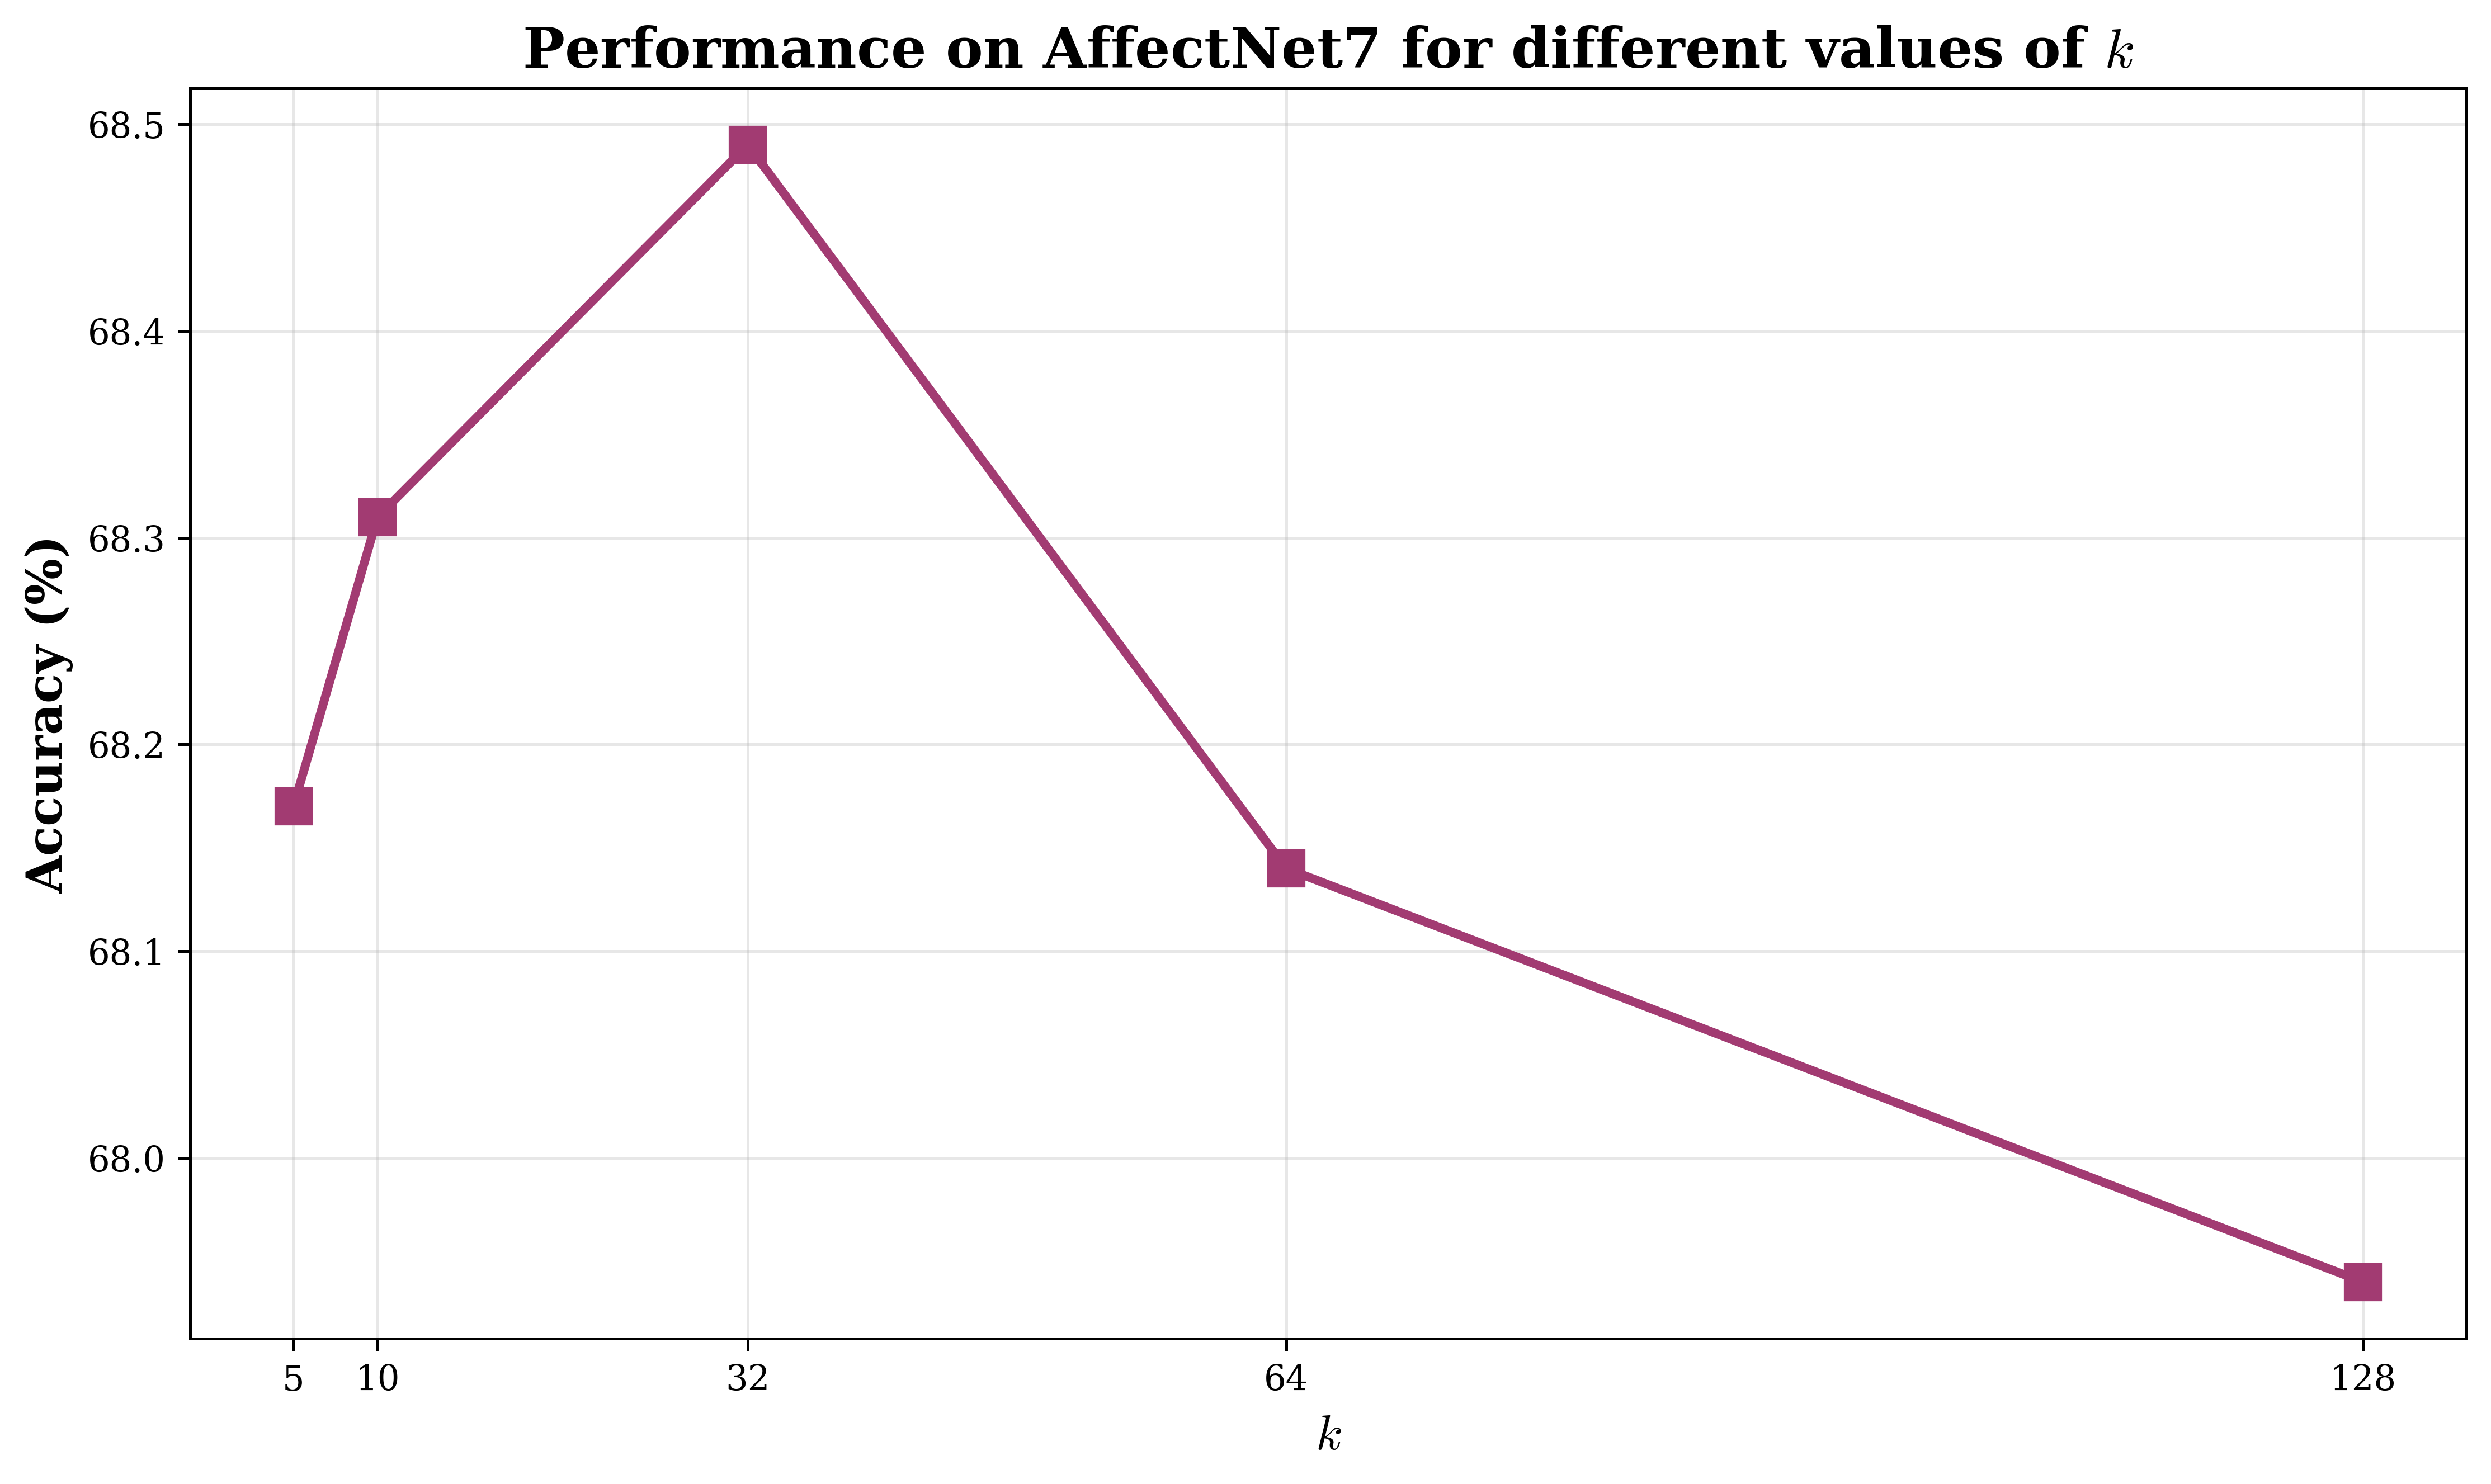

In [9]:
# k_param plotting - RAF-DB
plt.rcParams['mathtext.fontset'] = 'cm'  # use Computer Modern for math
plt.rcParams['mathtext.rm'] = 'serif'
plt.rcParams['font.family'] = 'serif'

fig1, ax1 = plt.subplots(figsize=(10, 6), dpi=450)
raf_data = k_param[k_param['dataset'] == 'RAF-DB'].sort_values('k')
ax1.plot(raf_data['k'], raf_data['acc'], marker='o', linewidth=2.5, markersize=10, color='#2E86AB')
ax1.set_xlabel(r'$k$', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax1.set_title('Performance on RAF-DB for different values of $k$', fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(raf_data['k'].unique())
plt.tight_layout()
plt.savefig('results/k_param_raf_db.png', dpi=450, bbox_inches='tight')
plt.show()

# k_param plotting - AffectNet7
fig2, ax2 = plt.subplots(figsize=(10, 6), dpi=450)
affectnet_data = k_param[k_param['dataset'] == 'AffectNet7'].sort_values('k')
ax2.plot(affectnet_data['k'], affectnet_data['acc'], marker='s', linewidth=2.5, markersize=10, color='#A23B72')
ax2.set_xlabel(r'$k$', fontsize=14, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax2.set_title('Performance on AffectNet7 for different values of $k$', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(affectnet_data['k'].unique())
plt.tight_layout()
plt.savefig('results/k_param_affectnet7.png', dpi=450, bbox_inches='tight')
plt.show()


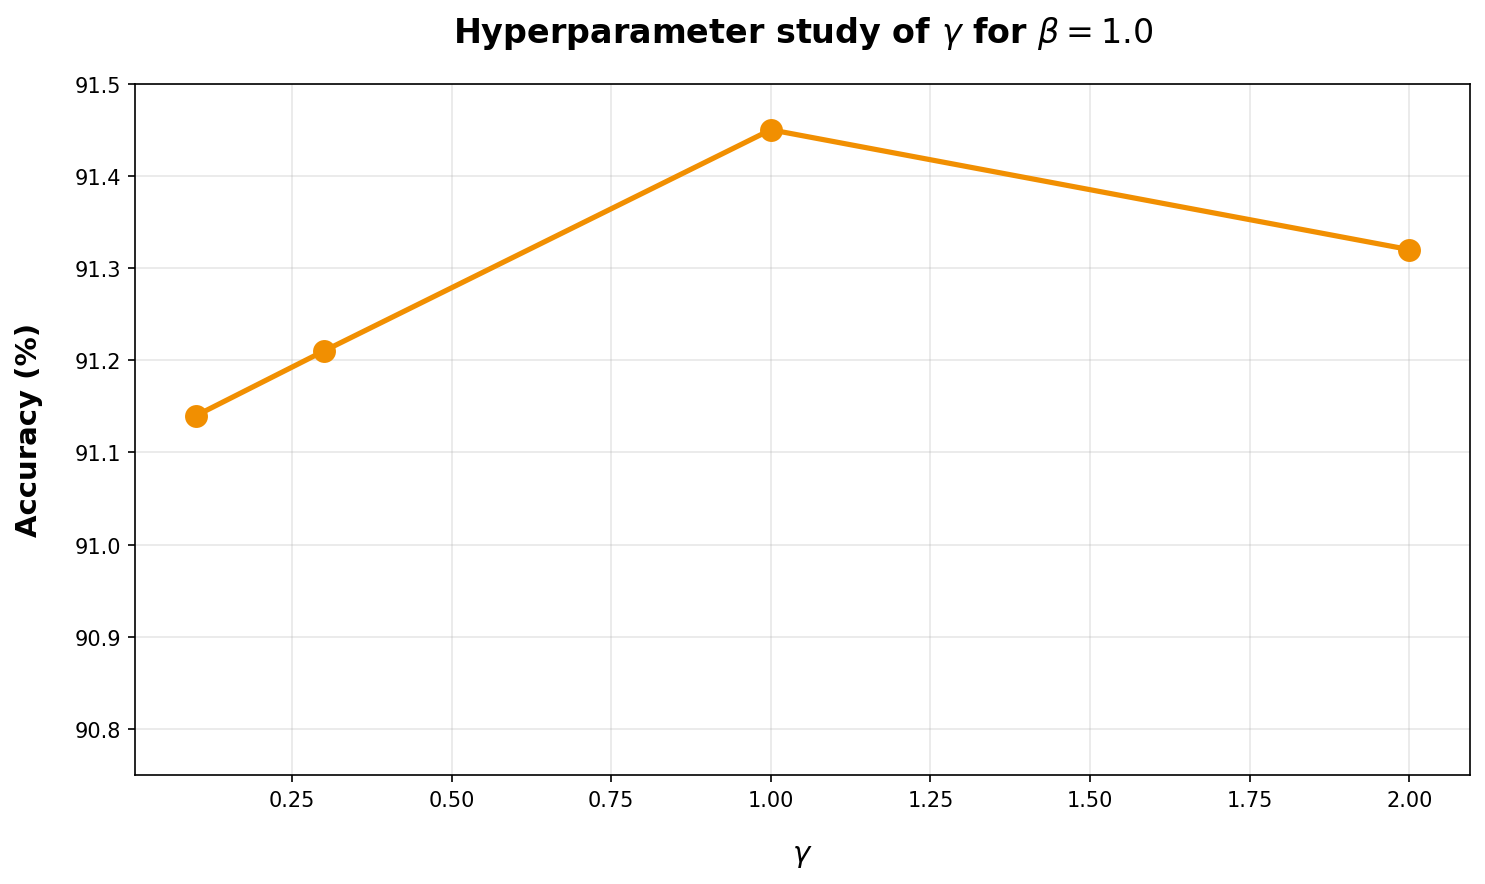

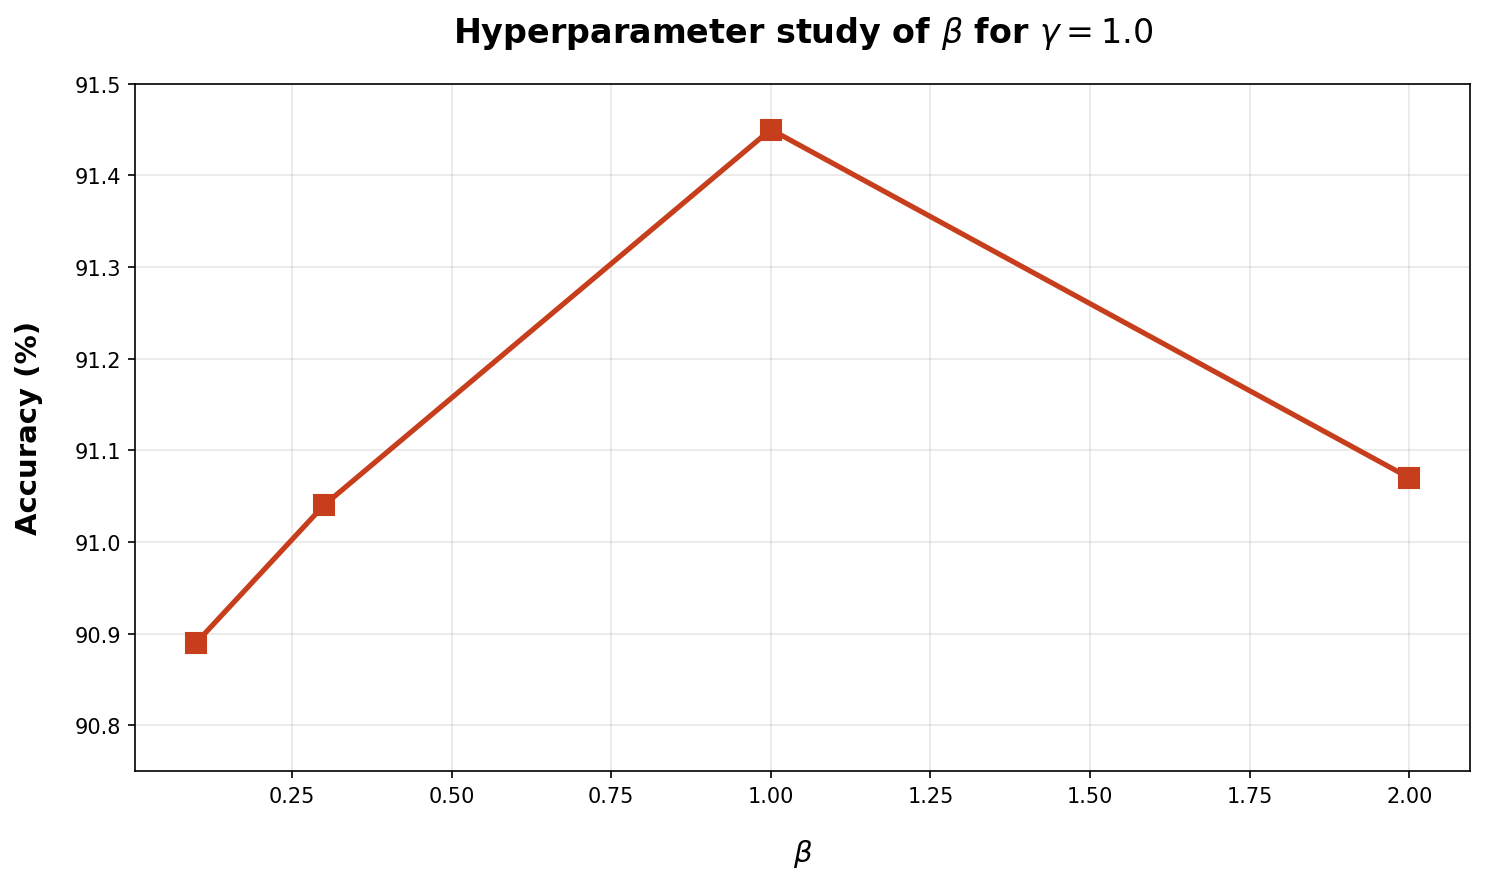

In [25]:
# gamma_beta plotting - beta==1 (varying etf)
fig3, ax3 = plt.subplots(figsize=(10, 6), dpi=150)
beta_data = gamma_beta[gamma_beta['beta'] == 1.0].sort_values('etf')
ax3.plot(beta_data['etf'], beta_data['acc'], marker='o', linewidth=2.5, markersize=10, color='#F18F01')
ax3.set_xlabel(r'$\gamma$', fontsize=14, fontweight='bold', labelpad=15)
ax3.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold', labelpad=15)
ax3.set_title(r'Hyperparameter study of $\gamma$ for $\beta=1.0$', fontsize=16, fontweight='bold', pad=20)
ax3.set_ylim(90.75, 91.5)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/gamma_beta_beta1.png', dpi=150, bbox_inches='tight')
plt.show()

# gamma_beta plotting - etf==1 (varying beta)
fig4, ax4 = plt.subplots(figsize=(10, 6), dpi=150)
etf_data = gamma_beta[gamma_beta['etf'] == 1.0].sort_values('beta')
ax4.plot(etf_data['beta'], etf_data['acc'], marker='s', linewidth=2.5, markersize=10, color='#C73E1D')
ax4.set_xlabel(r'$\beta$', fontsize=14, fontweight='bold', labelpad=15)
ax4.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold', labelpad=15)
ax4.set_title(r'Hyperparameter study of $\beta$ for $\gamma=1.0$', fontsize=16, fontweight='bold', pad=20)
ax4.set_ylim(90.75, 91.5)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/gamma_beta_etf1.png', dpi=150, bbox_inches='tight')
plt.show()


In [2]:
table = pd.read_excel('results/mine1/table.xlsx')
table['f1_score'] = table['f1_score'] * 100

In [3]:
table.head()

,model_name,dataset_name,imb_factor,f1_score,balanced_accuracy,macro_precision,macro_recall,auc,ckpt_path,many,medium,few,macro_accuracy,micro_acc
0,CAER_CE,CAER,1.0,90.845246,90.915611,90.812404,90.915611,0.980683,checkpoint/CAER_CE_predictions.pth,95.215072,91.797266,87.461094,90.915611,90.915587
1,CAER_CE_ETF,CAER,1.0,90.556470,90.658391,90.535608,90.658391,0.977984,checkpoint/CAER_CE_ETF_predictions.pth,94.514838,91.197066,87.727879,90.658391,90.658346
2,CAER_KBCL,CAER,1.0,91.192408,91.234802,91.177699,91.234802,0.979663,checkpoint/CAER_KBCL_predictions.pth,94.531511,91.347116,88.961761,91.234802,91.234756
3,CAER_KBCL_ETF,CAER,1.0,91.377757,91.463400,91.417801,91.463400,0.976198,checkpoint/CAER_KBCL_ETF_predictions.pth,96.232077,93.297766,87.060916,91.463400,91.463415
4,raf_CE,RAF-DB,1.0,87.680528,86.081614,90.027733,86.081614,0.954120,checkpoint/raf_CE_predictions.pth,96.962025,92.141623,85.517241,86.081614,92.438070


In [4]:
def process_name(name):
    # 첫 번째 underscore를 기준으로 split (Datasetname_ 부분 제거)
    parts = name.split('_', 1)
    if len(parts) > 1:
        return parts[1]
    return name

In [5]:
dataset_names = ['CAER', 'RAF-DB', 'AffectNet']

# Create dictionary to store tables for each dataset



In [10]:
# Filter columns for each dataset
dataset_tables = {}

for dataset_name in dataset_names:
    dataset_tables[dataset_name] = table[table['dataset_name'] == dataset_name]

for dataset_name in dataset_names:
    dataset_tables[dataset_name] = dataset_tables[dataset_name].filter(regex='model_name|f1_score|balanced_accuracy|macro_recall|macro_acc|micro_acc')
    dataset_tables[dataset_name]['model_name'] = dataset_tables[dataset_name]['model_name'].apply(process_name)

all_latex_tables = {}

for dataset_name in dataset_names:
    print(dataset_tables[dataset_name].head())
    latex_str = dataset_tables[dataset_name].to_latex(
        index=False,
        float_format=lambda x: f'{x:.2f}',
        escape=False,
        caption=f'{dataset_name} Results',
        label=f'tab:{dataset_name.lower()}_results'
    )
    all_latex_tables[dataset_name] = latex_str
    
    # Save to individual file
    filename = f'results/{dataset_name.lower()}_metric_table.txt'
    with open(filename, 'w') as f:
        f.write(latex_str)
    
    print(f"✓ Saved {dataset_name} table to {filename}")

# Save all tables to a single combined file
combined_filename = 'results/all_tables.txt'
with open(combined_filename, 'w') as f:
    for dataset_name in dataset_names:
        f.write(f"\n\n{'='*60}\n")
        f.write(f"LaTeX Table for {dataset_name}\n")
        f.write(f"{'='*60}\n\n")
        f.write(all_latex_tables[dataset_name])

print(f"\n✓ Saved all tables combined to {combined_filename}")


  model_name   f1_score  balanced_accuracy  macro_recall  macro_accuracy  \
0         CE  90.845246          90.915611     90.915611       90.915611   
1     CE_ETF  90.556470          90.658391     90.658391       90.658391   
2       KBCL  91.192408          91.234802     91.234802       91.234802   
3   KBCL_ETF  91.377757          91.463400     91.463400       91.463400   

   micro_acc  
0  90.915587  
1  90.658346  
2  91.234756  
3  91.463415  
✓ Saved CAER table to results/caer_metric_table.txt
   model_name   f1_score  balanced_accuracy  macro_recall  macro_accuracy  \
4          CE  87.680528          86.081614     86.081614       86.081614   
5      CE_ETF  87.178129          86.908351     86.908351       86.908351   
6        KBCL  88.202293          87.823834     87.823834       87.823834   
7    KBCL_ETF  87.149640          86.142110     86.142110       86.142110   
16        SCL  87.557758          87.128419     87.128419       87.128419   

    micro_acc  
4   92.438070

In [7]:
# LaTeX table format for each dataset - Save to files

# Filter columns for each dataset
dataset_tables = {}

for dataset_name in dataset_names:
    dataset_tables[dataset_name] = table[table['dataset_name'] == dataset_name]

for dataset_name in dataset_names:
    dataset_tables[dataset_name] = dataset_tables[dataset_name].filter(regex='model_name|many|medium|few|macro_accuracy')
    dataset_tables[dataset_name]['model_name'] = dataset_tables[dataset_name]['model_name'].apply(process_name)

all_latex_tables = {}

for dataset_name in dataset_names:
    latex_str = dataset_tables[dataset_name].to_latex(
        index=False,
        float_format=lambda x: f'{x:.2f}',
        escape=False,
        caption=f'{dataset_name} Results',
        label=f'tab:{dataset_name.lower()}_results'
    )
    all_latex_tables[dataset_name] = latex_str
    
    # Save to individual file
    filename = f'results/{dataset_name.lower()}_category_table.txt'
    with open(filename, 'w') as f:
        f.write(latex_str)
    
    print(f"✓ Saved {dataset_name} table to {filename}")

# Save all tables to a single combined file
combined_filename = 'results/all_tables.txt'
with open(combined_filename, 'w') as f:
    for dataset_name in dataset_names:
        f.write(f"\n\n{'='*60}\n")
        f.write(f"LaTeX Table for {dataset_name}\n")
        f.write(f"{'='*60}\n\n")
        f.write(all_latex_tables[dataset_name])

print(f"\n✓ Saved all tables combined to {combined_filename}")


✓ Saved CAER table to results/caer_category_table.txt
✓ Saved RAF-DB table to results/raf-db_category_table.txt
✓ Saved AffectNet table to results/affectnet_category_table.txt

✓ Saved all tables combined to results/all_tables.txt


In [12]:
# Download checkpoint files from remote server using scp
paths = table['ckpt_path']
for path in paths:
    filename = path.split('/')[-1]
    command = f'scp -r mine1:/home/mj/rl/{path} checkpoint/{filename}'
    
    try:
        print(f"Executing: {command}")
        result = subprocess.run(command, shell=True, check=True, capture_output=True, text=True)
        print(f"✓ Successfully downloaded: {filename}")
        if result.stdout:
            print(f"  Output: {result.stdout}")
    except subprocess.CalledProcessError as e:
        print(f"✗ Error downloading {filename}: {e.stderr}") 

Executing: scp -r mine1:/home/mj/rl/checkpoint/CAER_CE_predictions.pth checkpoint/CAER_CE_predictions.pth
✓ Successfully downloaded: CAER_CE_predictions.pth
Executing: scp -r mine1:/home/mj/rl/checkpoint/CAER_CE_ETF_predictions.pth checkpoint/CAER_CE_ETF_predictions.pth
✓ Successfully downloaded: CAER_CE_ETF_predictions.pth
Executing: scp -r mine1:/home/mj/rl/checkpoint/CAER_KBCL_predictions.pth checkpoint/CAER_KBCL_predictions.pth
✓ Successfully downloaded: CAER_KBCL_predictions.pth
Executing: scp -r mine1:/home/mj/rl/checkpoint/CAER_KBCL_ETF_predictions.pth checkpoint/CAER_KBCL_ETF_predictions.pth
✓ Successfully downloaded: CAER_KBCL_ETF_predictions.pth
Executing: scp -r mine1:/home/mj/rl/checkpoint/raf_CE_predictions.pth checkpoint/raf_CE_predictions.pth
✓ Successfully downloaded: raf_CE_predictions.pth
Executing: scp -r mine1:/home/mj/rl/checkpoint/raf_CE_ETF_predictions.pth checkpoint/raf_CE_ETF_predictions.pth
✓ Successfully downloaded: raf_CE_ETF_predictions.pth
Executing: scp -

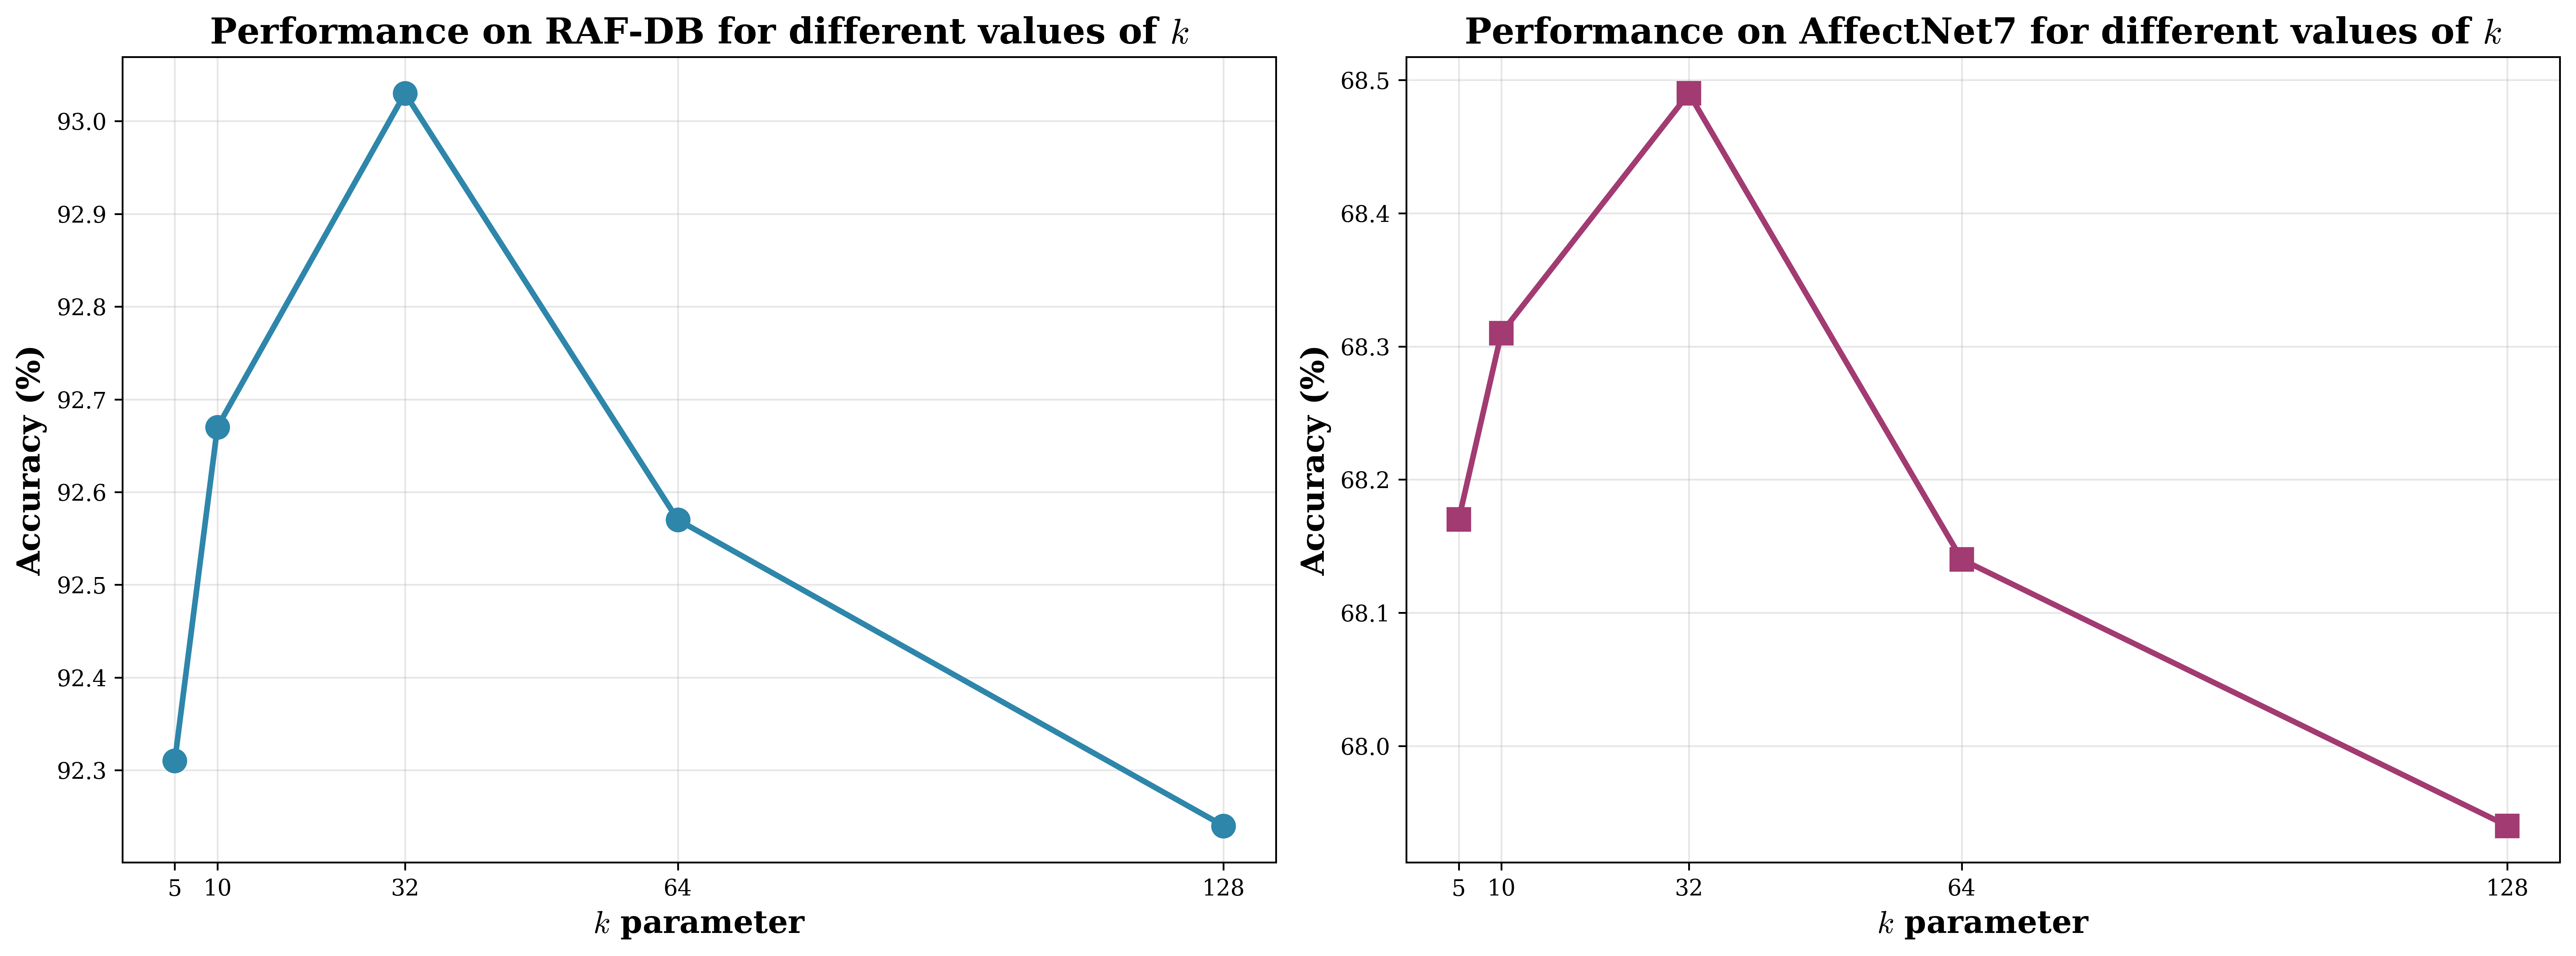

In [10]:
# Combined k_param analysis plot
plt.rcParams.update({
    'mathtext.fontset': 'cm',
    'mathtext.rm': 'serif',
    'font.family': 'serif'
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=450)

# RAF-DB subplot
raf_data = k_param[k_param['dataset'] == 'RAF-DB'].sort_values('k')
axes[0].plot(raf_data['k'], raf_data['acc'], marker='o', linewidth=2.5, markersize=10, color='#2E86AB')
axes[0].set_xlabel(r'$k$ parameter', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
axes[0].set_title('Performance on RAF-DB for different values of $k$', fontsize=16, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(raf_data['k'].unique())

# AffectNet7 subplot
affectnet_data = k_param[k_param['dataset'] == 'AffectNet7'].sort_values('k')
axes[1].plot(affectnet_data['k'], affectnet_data['acc'], marker='s', linewidth=2.5, markersize=10, color='#A23B72')
axes[1].set_xlabel(r'$k$ parameter', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
axes[1].set_title('Performance on AffectNet7 for different values of $k$', fontsize=16, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(affectnet_data['k'].unique())

plt.tight_layout()
plt.savefig('results/k_param_analysis.png', dpi=450, bbox_inches='tight')
plt.show()


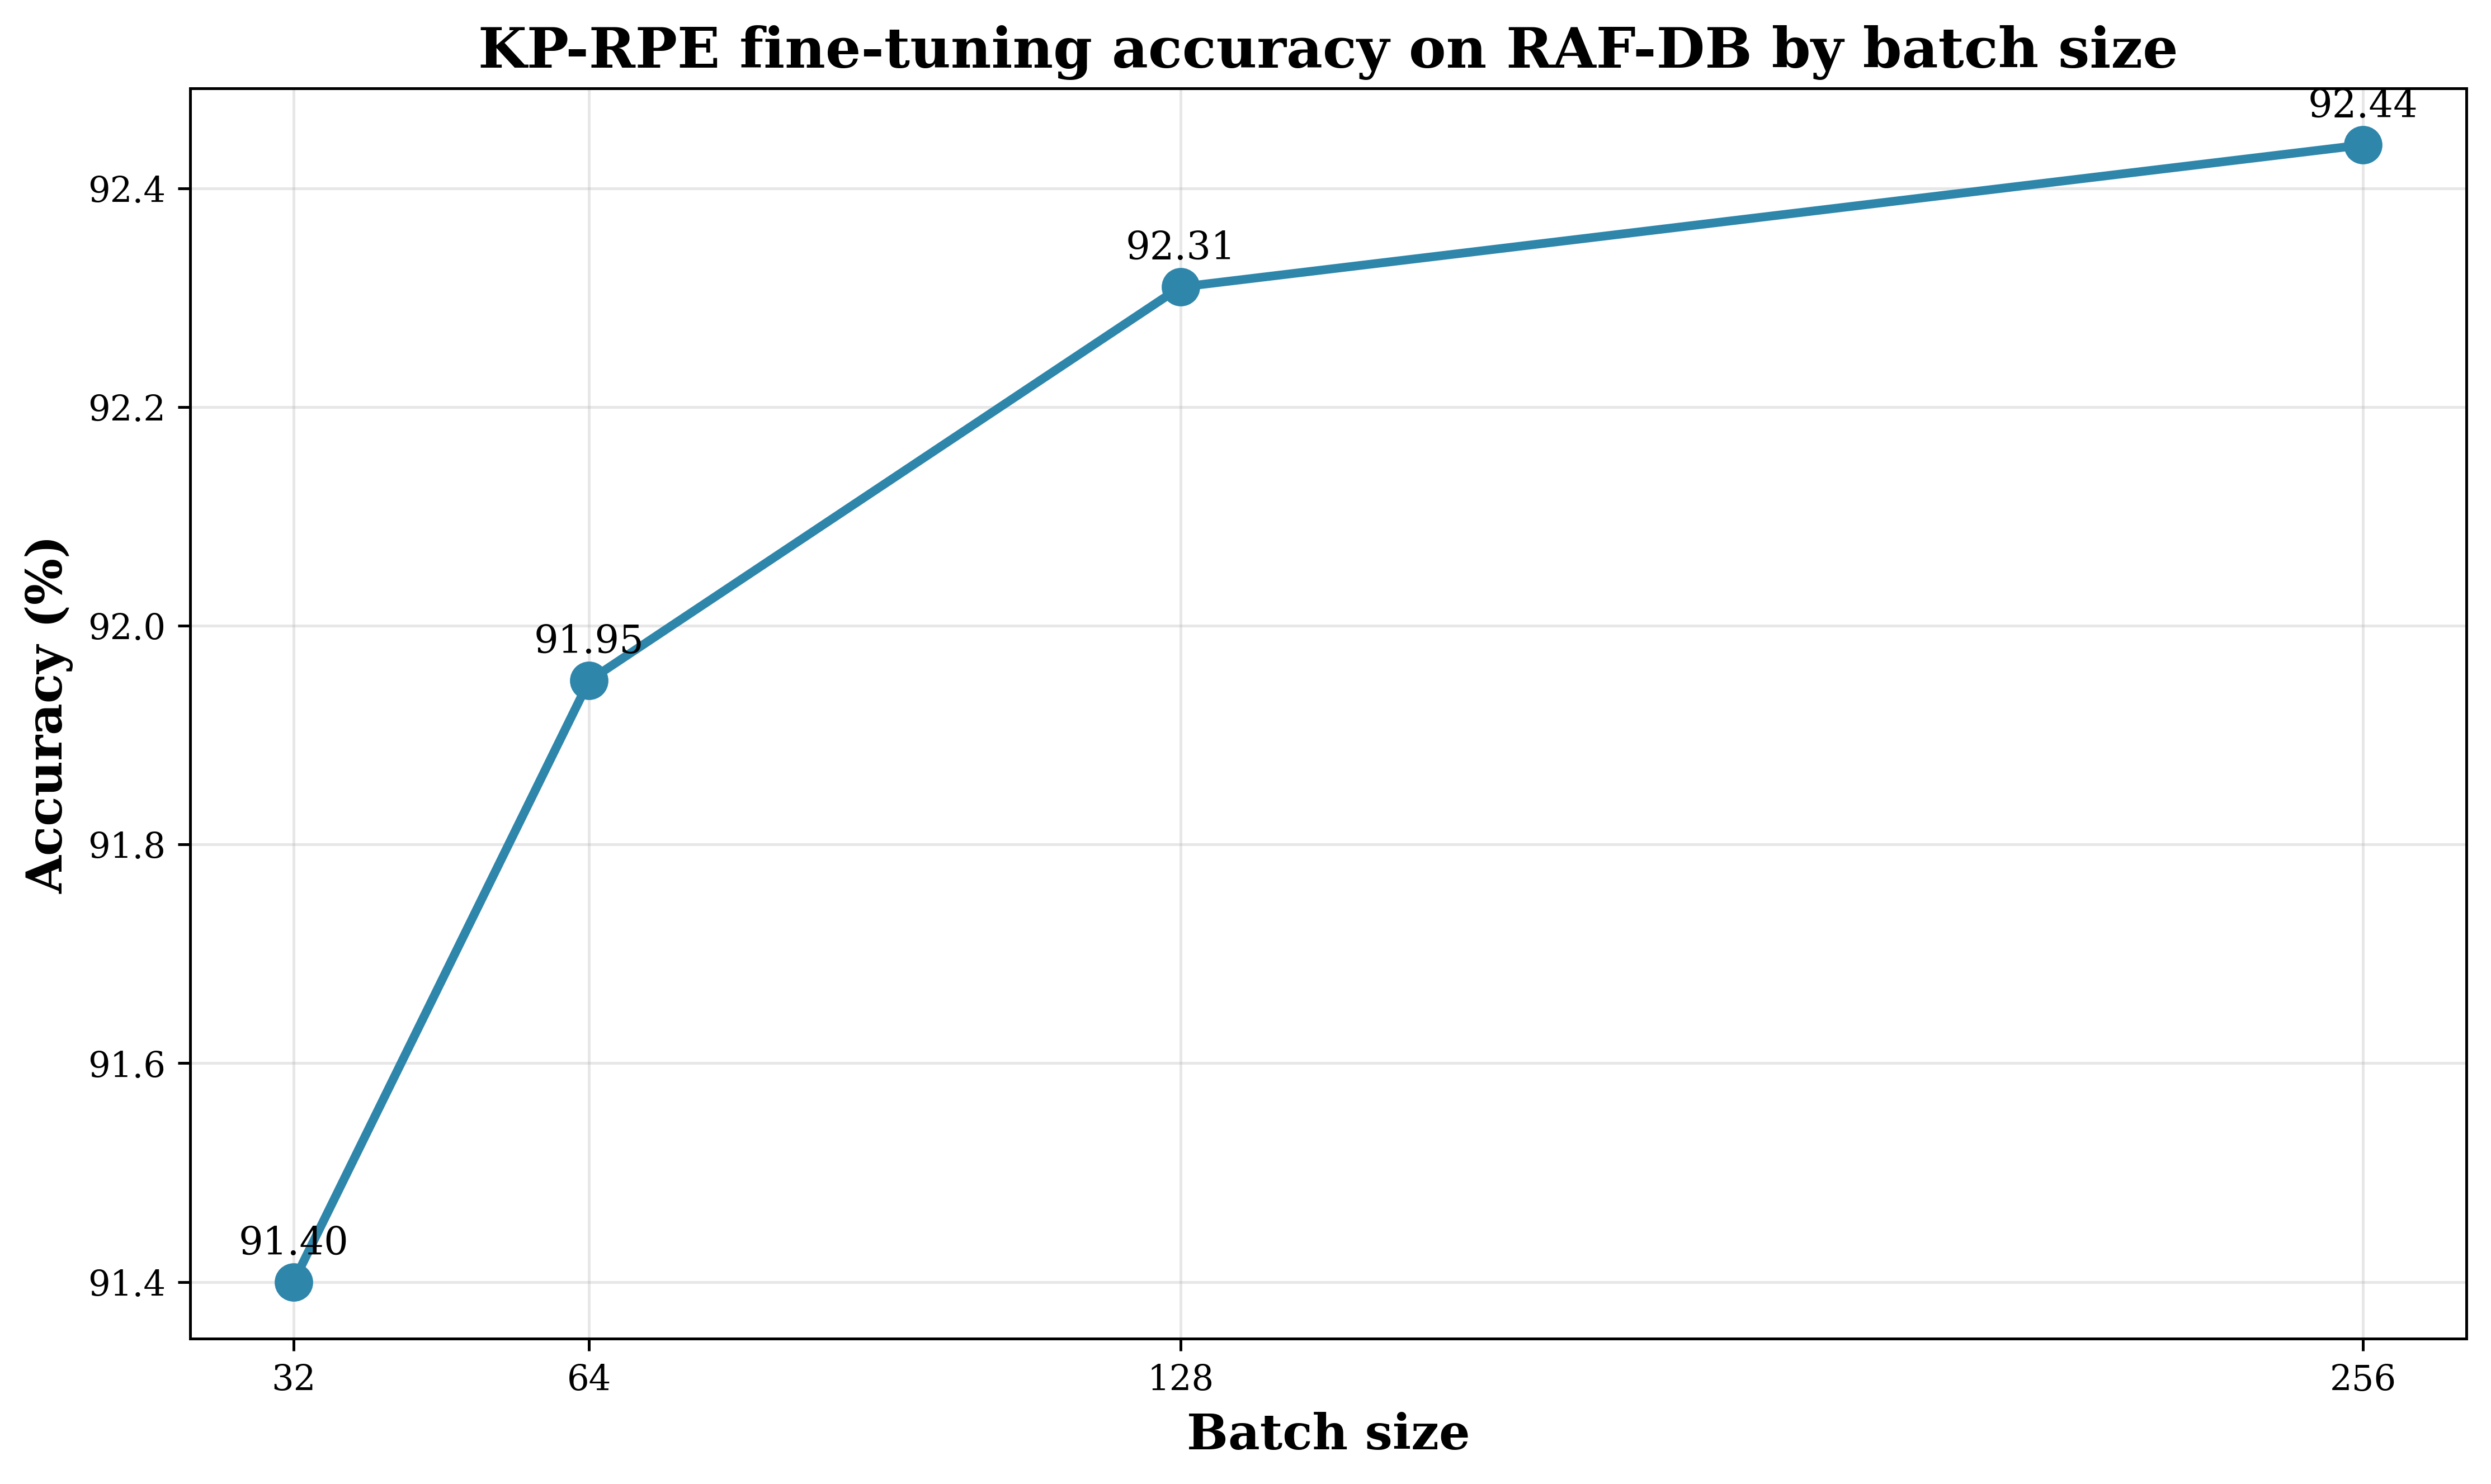

In [2]:
bs = [32, 64, 128, 256]
acc = [91.4, 91.95, 92.31, 92.44]

# KP-RPE fine-tuning accuracy on RAF-DB by batch size
plt.rcParams.update({
    'mathtext.fontset': 'cm',
    'mathtext.rm': 'serif',
    'font.family': 'serif'
})

fig, ax = plt.subplots(figsize=(10, 6), dpi=450)
ax.plot(bs, acc, marker='o', linewidth=2.5, markersize=10, color='#2E86AB')
ax.set_xlabel('Batch size', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('KP-RPE fine-tuning accuracy on RAF-DB by batch size', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(bs)

for x, y in zip(bs, acc):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('results/kprpe_batchsize_rafdb.png', dpi=450, bbox_inches='tight')
plt.show()
